# SY09 – Projet : Student Alcohol Consumption

**Problématique :** Dans quelle mesure les facteurs socio-éducatifs et familiaux influencent-ils la consommation d'alcool des étudiants et quel est l'impact de cette consommation sur leur réussite scolaire ?

## Partie 0 - Chargement et préparation des données

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import copy as cp
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import adjusted_rand_score, rand_score
from sklearn.metrics import log_loss
from scipy.cluster.hierarchy import dendrogram
from sklearn.preprocessing import PolynomialFeatures
import scipy.stats as spst

In [2]:
# Quelques fonctions utilitaires (TDs) : 
def add_labels(x, y, labels, ax=None):
    """Ajoute des étiquettes texte à un scatter plot."""
    if ax is None:
        ax = plt.gca()
    for xi, yi, lab in zip(x, y, labels):
        ax.annotate(str(lab), (xi, yi), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")


def scatterplot_pca(data, hue, style=None, columns=None, ax=None, title=""):
    """
    Visualise un DataFrame dans son premier plan factoriel (ACP).
    Réplique la fonction scatterplot_pca du TD6.
    """
    if ax is None:
        fig, ax = plt.subplots()
    if columns is None:
        columns = data.columns.tolist()
    Xsc = StandardScaler().fit_transform(data[columns])
    pcs = PCA(n_components=2).fit_transform(Xsc)
    df_plot = pd.DataFrame({"PC1": pcs[:, 0], "PC2": pcs[:, 1],
                             "hue": hue})
    if style is not None:
        df_plot["style"] = style
        sns.scatterplot(x="PC1", y="PC2", hue="hue", style="style",
                        data=df_plot, ax=ax)
    else:
        sns.scatterplot(x="PC1", y="PC2", hue="hue", data=df_plot, ax=ax)
    ax.set_title(title)
    return ax


def plot_dendrogram(model, ax=None, **kwargs):
    """
    Trace le dendrogramme à partir d'un AgglomerativeClustering
    (distance_threshold=0, n_clusters=None).
    Réplique plot_dendrogram du TD5.
    """
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    linkage_matrix = np.column_stack([
        model.children_, model.distances_, counts
    ]).astype(float)
    if ax is None:
        ax = plt.gca()
    dendrogram(linkage_matrix, ax=ax, **kwargs)
    return ax

In [3]:
# Lecture des deux fichiers
mat = pd.read_csv("../data/student-mat.csv", sep=",")
por = pd.read_csv("../data/student-por.csv", sep=",")

print(f"Math  : {mat.shape[0]} individus, {mat.shape[1]} variables")
print(f"Portugais : {por.shape[0]} individus, {por.shape[1]} variables")

# Fusion sur les colonnes d'identité
identity_cols = [
        "school", "sex", "age", "address", "famsize", "Pstatus",
        "Medu", "Fedu", "Mjob", "Fjob", "reason", "guardian",
        "traveltime", "studytime", 
        "schoolsup", "famsup", "activities", "nursery",
        "higher", "internet", "romantic",
        "famrel", "freetime", "goout", "Dalc", "Walc",
        "health"
    ]
df = pd.merge(
        mat, por,
        how='outer',  
        on=identity_cols,
        suffixes=('_mat', '_por')
    )
print(f"Fusionné : {df.shape[0]} individus communs, {df.shape[1]} variables\n")

# Traitement des types (Nominal et Ordinal)
nominal_cols = [
        "school", "sex", "address", "famsize", "Pstatus",
        "Mjob", "Fjob", "reason", "guardian", "nursery",
        "higher", "internet", "romantic",
        "schoolsup", "famsup", "activities",
        "paid_mat", "paid_por"
    ]

for col in nominal_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

edu_type = pd.CategoricalDtype(categories=[0, 1, 2, 3, 4], ordered=True)
travel_study_type = pd.CategoricalDtype(categories=[1, 2, 3, 4], ordered=True)
failures_type = pd.CategoricalDtype(categories=[0, 1, 2, 3], ordered=True)
likert_5_type = pd.CategoricalDtype(categories=[1, 2, 3, 4, 5], ordered=True)

ordinal_map = {
    edu_type: ["Medu", "Fedu"],
    travel_study_type: ["traveltime", "studytime"],
    failures_type: ["failures_mat", "failures_por"], 
    likert_5_type: ["famrel", "freetime", "goout", "Dalc", "Walc", "health"],
    }

for dtype, cols in ordinal_map.items():
    for col in cols:
        if col in df.columns:
            df[col] = df[col].astype(dtype)

    # Aperçu des données:
    print(df.head(3))
    print("\nTypes :")
    print(df.dtypes)
    print("\nStatistiques descriptives :")
    print(df.describe(include='all'))

    # Transformations des var textuelles en nombres
    cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
    le = LabelEncoder()
    df_enc = df.copy()
    
    for col in cat_cols:
        df_enc[col] = le.fit_transform(df[col].astype(str))

        # réussite mat : NaN si pas de note, sinon 1 si G3 >= 10
    df["reussite_mat"] = df["G3_mat"].apply(lambda x: int(x >= 10) if pd.notna(x) else np.nan)

    # réussite por : pareil
    df["reussite_por"] = df["G3_por"].apply(lambda x: int(x >= 10) if pd.notna(x) else np.nan)

    # réussite globale : moyenne des deux notes disponibles (ignore les NaN)
    # NaN seulement si les DEUX notes sont manquantes
    df["reussite"] = df[["G3_mat", "G3_por"]].mean(axis=1).apply(lambda x: int(x >= 10) if pd.notna(x) else np.nan)

    print(f"\nDistribution réussite moyenne (G3 >= 10) :")
    print(df["reussite"].value_counts())
    
    # Sauvegarder les données
    df.to_csv("../data/merged.csv", index=False)

Math  : 395 individus, 33 variables
Portugais : 649 individus, 33 variables
Fusionné : 674 individus communs, 39 variables

  school sex  age address famsize Pstatus Medu Fedu     Mjob   Fjob  ...  \
0     GP   F   15       R     GT3       T    1    1  at_home  other  ...   
1     GP   F   15       R     GT3       T    1    1    other  other  ...   
2     GP   F   15       R     GT3       T    1    1    other  other  ...   

  absences_mat G1_mat  G2_mat  G3_mat  failures_por paid_por absences_por  \
0          2.0    7.0    10.0    10.0           0.0      yes          4.0   
1          NaN    NaN     NaN     NaN           1.0       no          2.0   
2          2.0    8.0     6.0     5.0           0.0       no          2.0   

  G1_por G2_por G3_por  
0   13.0   13.0   13.0  
1    8.0    9.0    9.0  
2   13.0   11.0   11.0  

[3 rows x 39 columns]

Types :
school          category
sex             category
age                int64
address         category
famsize         category
Pstat

## Partie 1 – Analyse exploratoire

In [4]:
# Création de colonnes supplémentaires (moyenne entre maths et portugais)
df["G1"] = df[["G1_mat", "G1_por"]].mean(axis=1)
df["G2"] = df[["G2_mat", "G2_por"]].mean(axis=1)
df["G3"] = df[["G3_mat", "G3_por"]].mean(axis=1)
df["absences"] = df[["absences_mat", "absences_por"]].mean(axis=1)
df["failures"] = df[["failures_mat", "failures_por"]].astype(float).mean(axis=1)

df_plot = df.copy()
df_plot["Walc"] = df_plot["Walc"].astype(float)
df_plot["Dalc"] = df_plot["Dalc"].astype(float)
df_plot["Totalc"] = df_plot["Walc"] + df_plot["Dalc"]

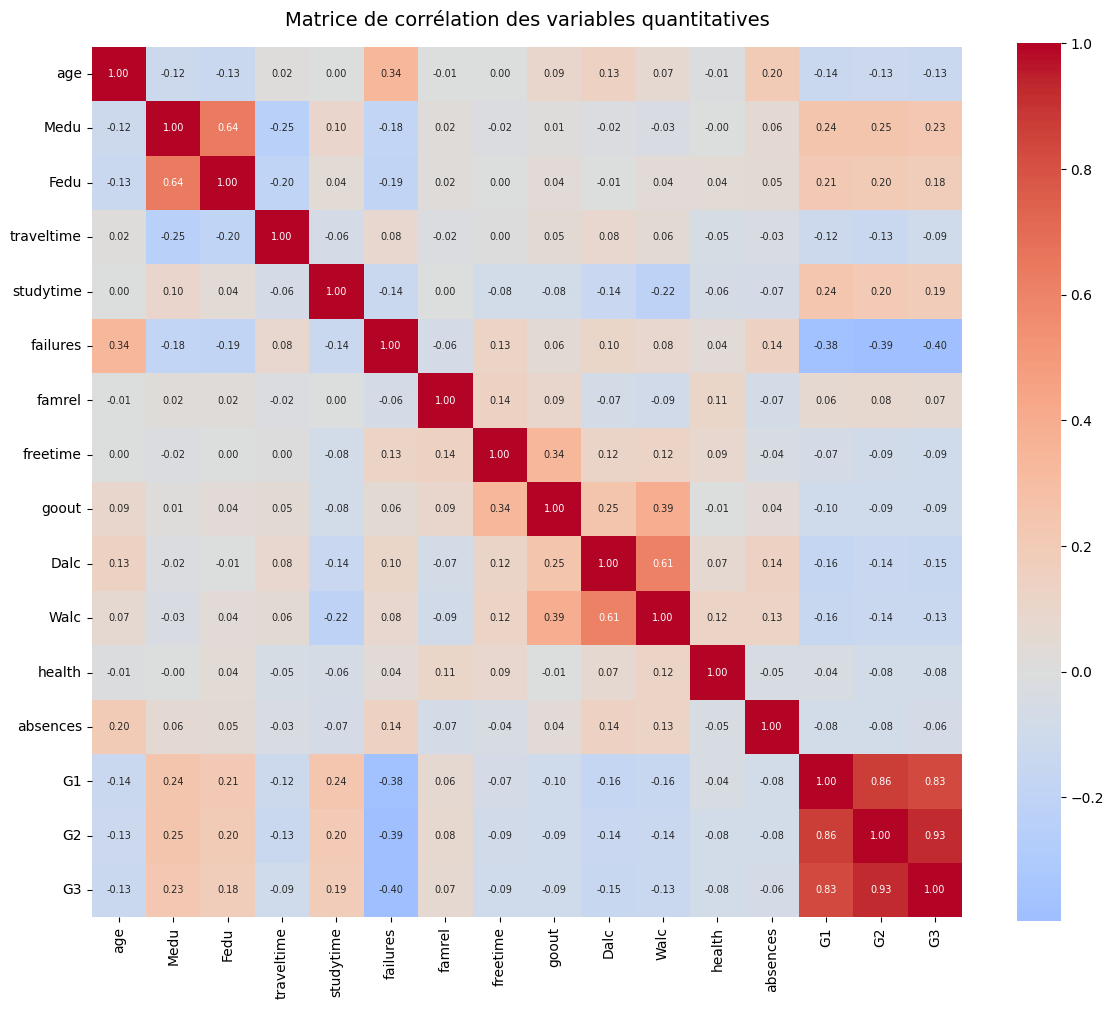


 Principales corrélations avec Walc (week-end)
Walc        1.000000
Dalc        0.613915
goout       0.391986
absences    0.126963
freetime    0.124526

 Principales corrélations avec Dalc (semaine)
Dalc        1.000000
Walc        0.613915
goout       0.245031
absences    0.137642
age         0.133358

 Principales corrélations avec G3 (note finale)
G3           1.000000
G2           0.928740
G1           0.832391
Medu         0.225387
studytime    0.189600


In [5]:
#Matrice de corrélation des variables quantitatives
quant_cols = [
    "age", "Medu", "Fedu", "traveltime", "studytime", "failures",
    "famrel", "freetime", "goout", "Dalc", "Walc",
    "health", "absences", "G1", "G2", "G3"
]

corr = df[quant_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", square=True,
            cmap="coolwarm", center=0, ax=ax,
            annot_kws={"size": 7})
ax.set_title("Matrice de corrélation des variables quantitatives", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print("\n Principales corrélations avec Walc (week-end)")
print(corr["Walc"].sort_values(ascending=False).head(5).to_string())
print("\n Principales corrélations avec Dalc (semaine)")
print(corr["Dalc"].sort_values(ascending=False).head(5).to_string())

print("\n Principales corrélations avec G3 (note finale)")
print(corr["G3"].sort_values(ascending=False).head(5).to_string())


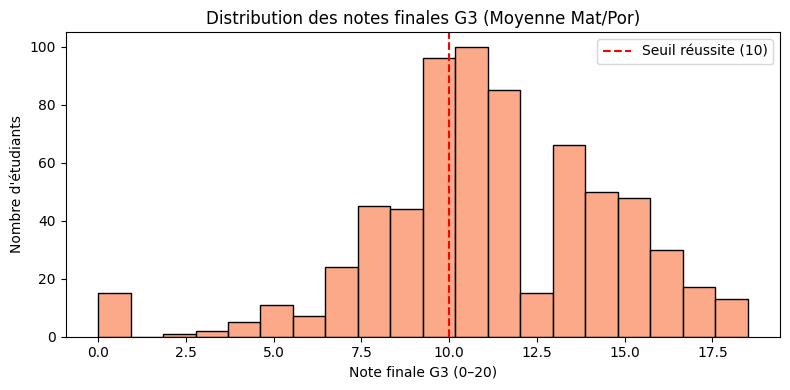

In [6]:
# Distribution des notes finales (G3 mat+por)
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["G3"], bins=20, ax=ax, color=sns.color_palette("Set2")[1])
ax.axvline(10, color="red", linestyle="--", label="Seuil réussite (10)")
ax.set_title("Distribution des notes finales G3 (Moyenne Mat/Por)")
ax.set_xlabel("Note finale G3 (0–20)")
ax.set_ylabel("Nombre d'étudiants")
ax.legend()
plt.tight_layout()
plt.show()

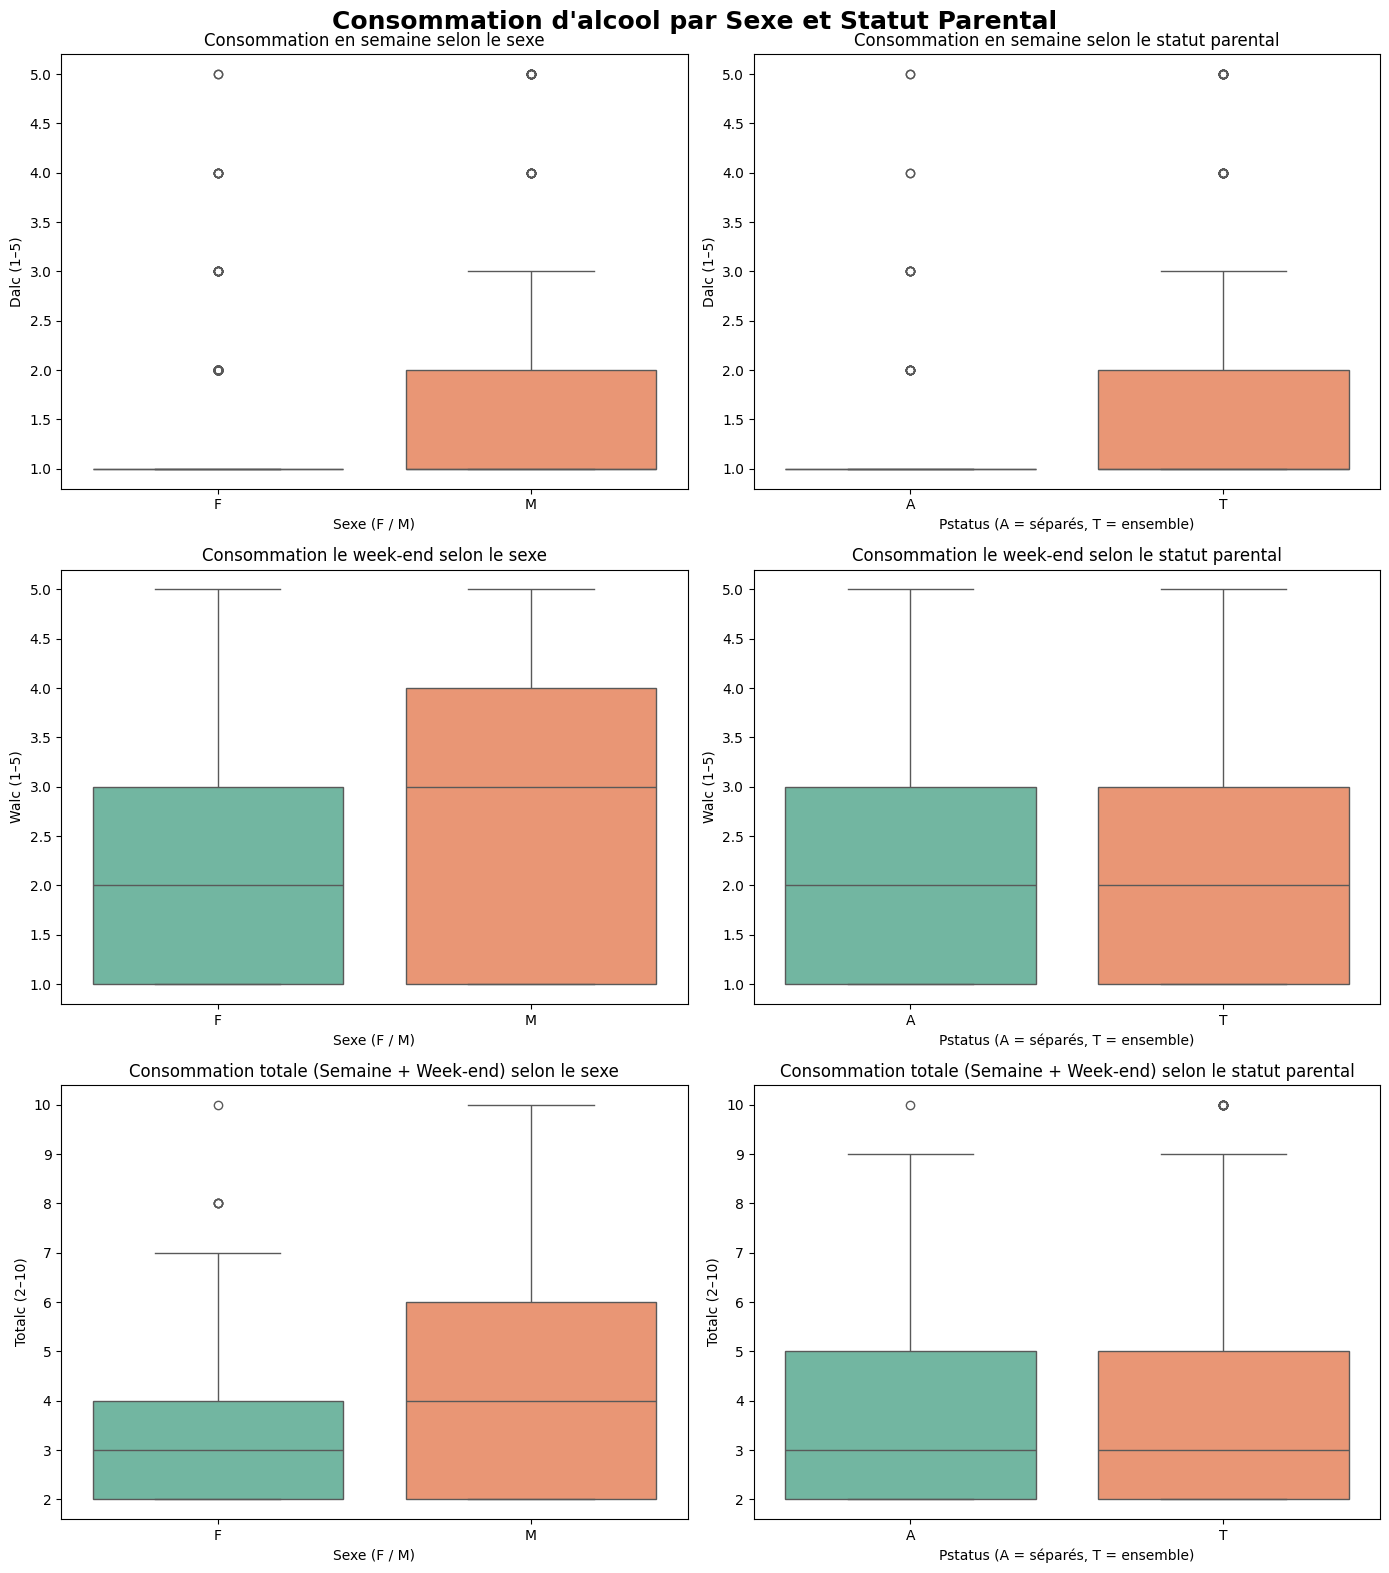

In [7]:
#Conso par sexe et par statut parental en fonction de Dalc, Walc et Total
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle("Consommation d'alcool par Sexe et Statut Parental", fontsize=18, fontweight='bold')

#Dalc
sns.boxplot(x="sex", y="Dalc", hue="sex", data=df_plot, ax=axes[0, 0], palette="Set2", legend=False)
axes[0, 0].set_title("Consommation en semaine selon le sexe")
axes[0, 0].set_xlabel("Sexe (F / M)")
axes[0, 0].set_ylabel("Dalc (1–5)")
sns.boxplot(x="Pstatus", y="Dalc", hue="Pstatus", data=df_plot, ax=axes[0, 1], palette="Set2", legend=False)
axes[0, 1].set_title("Consommation en semaine selon le statut parental")
axes[0, 1].set_xlabel("Pstatus (A = séparés, T = ensemble)")
axes[0, 1].set_ylabel("Dalc (1–5)")

#Walc
sns.boxplot(x="sex", y="Walc", hue="sex", data=df_plot, ax=axes[1, 0], palette="Set2", legend=False)
axes[1, 0].set_title("Consommation le week-end selon le sexe")
axes[1, 0].set_xlabel("Sexe (F / M)")
axes[1, 0].set_ylabel("Walc (1–5)")
sns.boxplot(x="Pstatus", y="Walc", hue="Pstatus", data=df_plot, ax=axes[1, 1], palette="Set2", legend=False)
axes[1, 1].set_title("Consommation le week-end selon le statut parental")
axes[1, 1].set_xlabel("Pstatus (A = séparés, T = ensemble)")
axes[1, 1].set_ylabel("Walc (1–5)")

#Totalc
sns.boxplot(x="sex", y="Totalc", hue="sex", data=df_plot, ax=axes[2, 0], palette="Set2", legend=False)
axes[2, 0].set_title("Consommation totale (Semaine + Week-end) selon le sexe")
axes[2, 0].set_xlabel("Sexe (F / M)")
axes[2, 0].set_ylabel("Totalc (2–10)")
sns.boxplot(x="Pstatus", y="Totalc", hue="Pstatus", data=df_plot, ax=axes[2, 1], palette="Set2", legend=False)
axes[2, 1].set_title("Consommation totale (Semaine + Week-end) selon le statut parental")
axes[2, 1].set_xlabel("Pstatus (A = séparés, T = ensemble)")
axes[2, 1].set_ylabel("Totalc (2–10)")

plt.tight_layout()
plt.show()

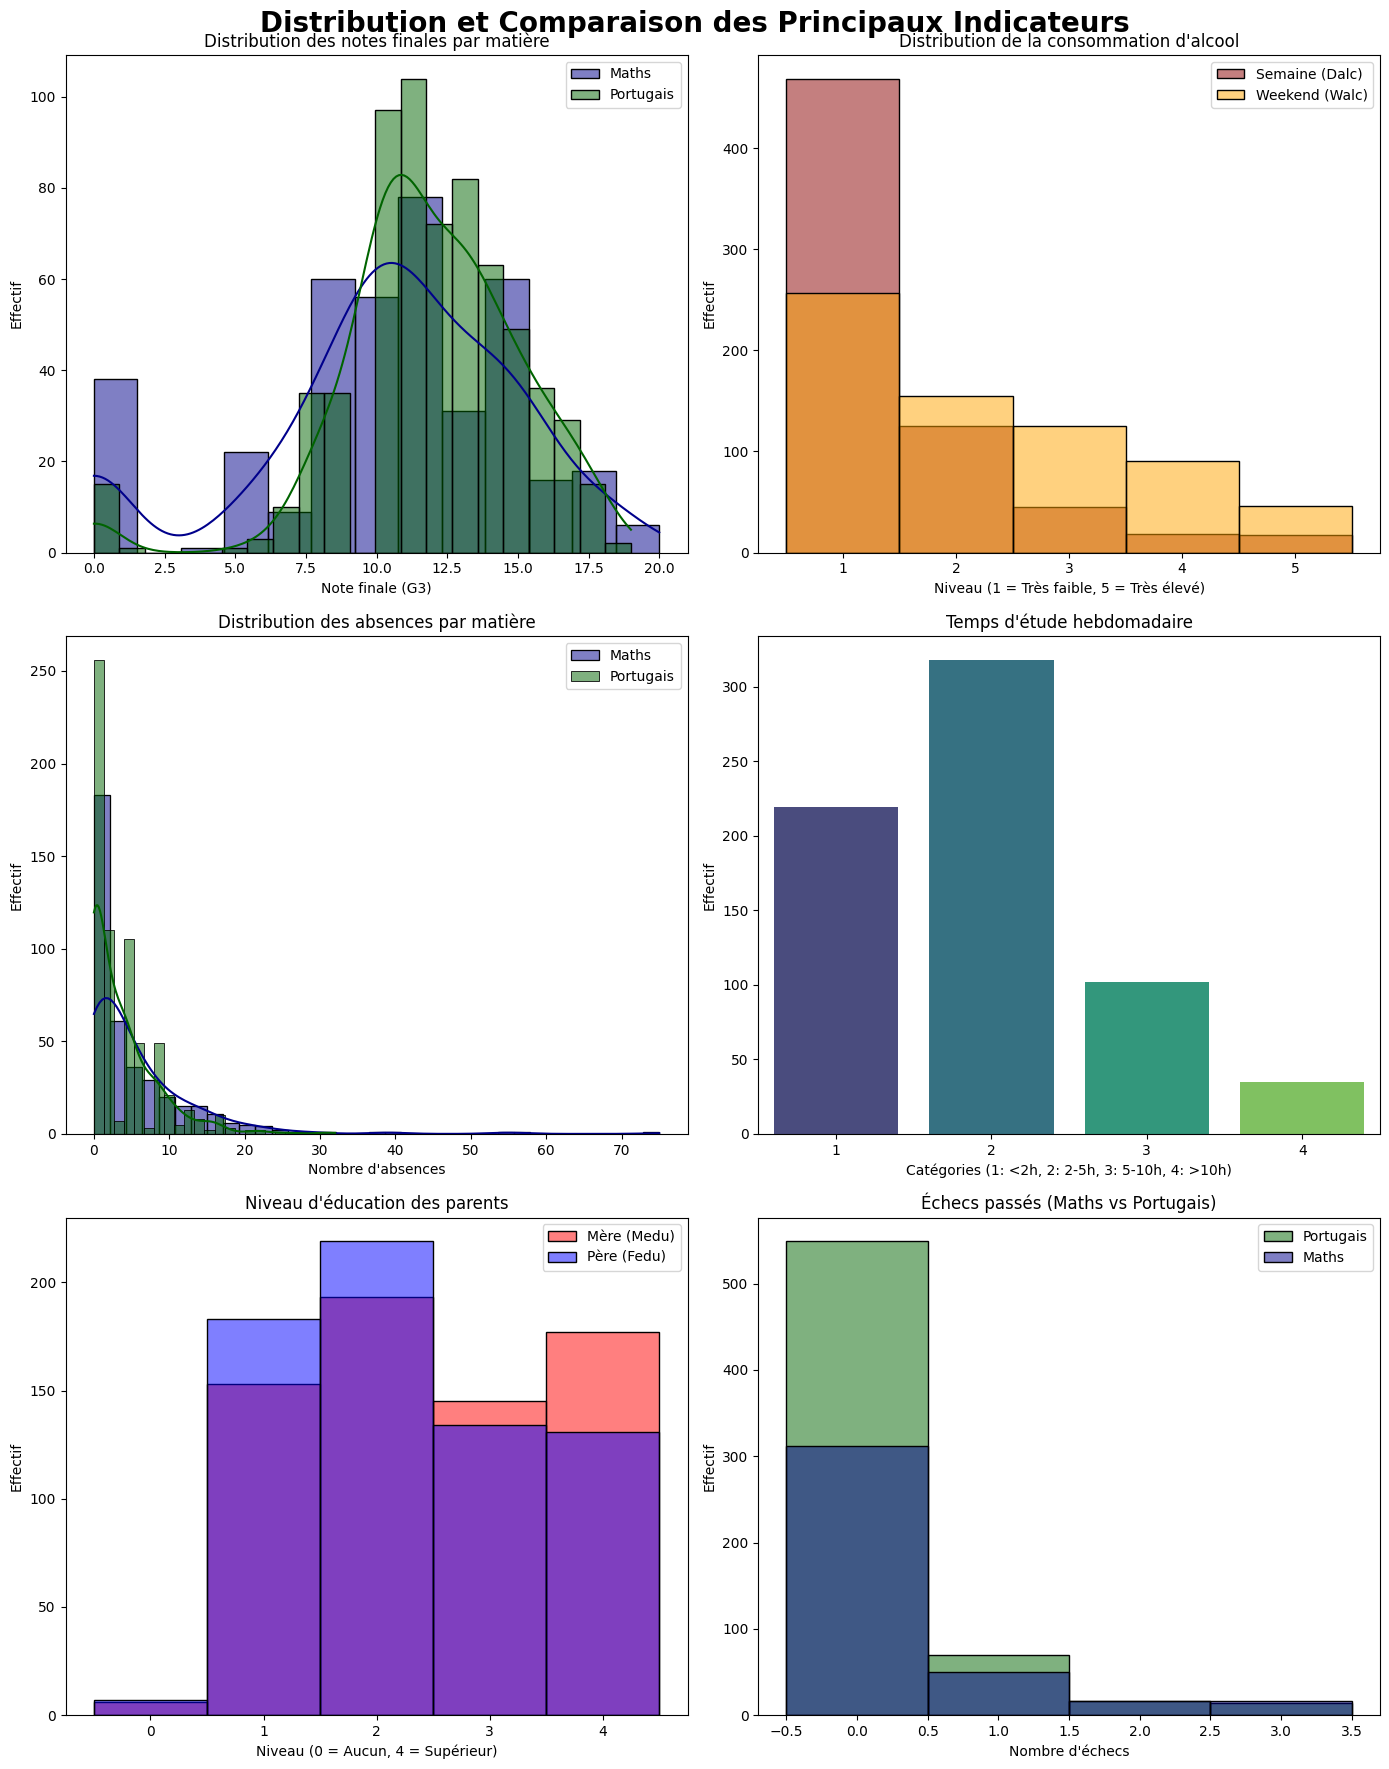

In [8]:
# Distribution et comparaison de quelques indicateurs supplémentaires
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
fig.suptitle('Distribution et Comparaison des Principaux Indicateurs', fontsize=20, fontweight='bold')

# Notes
sns.histplot(df['G3_mat'].dropna(), ax=axes[0, 0], color='darkblue', label='Maths', kde=True, stat='count', alpha=0.5)
sns.histplot(df['G3_por'].dropna(), ax=axes[0, 0], color='darkgreen', label='Portugais', kde=True, stat='count', alpha=0.5)
axes[0, 0].set_title('Distribution des notes finales par matière', fontsize=12)
axes[0, 0].set_xlabel('Note finale (G3)')
axes[0, 0].set_ylabel('Effectif')
axes[0, 0].legend()

# Conso d'alcool
sns.histplot(df['Dalc'].astype(float), ax=axes[0, 1], color='darkred', label='Semaine (Dalc)', stat='count', alpha=0.5, discrete=True)
sns.histplot(df['Walc'].astype(float), ax=axes[0, 1], color='orange', label='Weekend (Walc)', stat='count', alpha=0.5, discrete=True)
axes[0, 1].set_title("Distribution de la consommation d'alcool", fontsize=12)
axes[0, 1].set_xlabel('Niveau (1 = Très faible, 5 = Très élevé)')
axes[0, 1].set_ylabel('Effectif')
axes[0, 1].legend()

# Absence
sns.histplot(df['absences_mat'].dropna(), kde=True, ax=axes[1, 0], color='darkblue', label='Maths')
sns.histplot(df['absences_por'].dropna(), kde=True, ax=axes[1, 0], color='darkgreen', label='Portugais')
axes[1, 0].set_title('Distribution des absences par matière', fontsize=12)
axes[1, 0].set_xlabel("Nombre d'absences")
axes[1, 0].set_ylabel('Effectif')
axes[1, 0].legend()

#Temps d'étude
sns.countplot(x=df['studytime'], hue=df['studytime'], ax=axes[1, 1], palette="viridis", legend=False)
axes[1, 1].set_title("Temps d'étude hebdomadaire", fontsize=12) 
axes[1, 1].set_xlabel('Catégories (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h)')
axes[1, 1].set_ylabel('Effectif')

# Éducation des parents
sns.histplot(df['Medu'].astype(float), bins=5, discrete=True, ax=axes[2, 0], color='red', alpha=0.5, label='Mère (Medu)')
sns.histplot(df['Fedu'].astype(float), bins=5, discrete=True, ax=axes[2, 0], color='blue', alpha=0.5, label='Père (Fedu)')
axes[2, 0].set_title("Niveau d'éducation des parents", fontsize=12)
axes[2, 0].set_xlabel('Niveau (0 = Aucun, 4 = Supérieur)')
axes[2, 0].set_ylabel('Effectif')
axes[2, 0].legend()

# Échecs passés
sns.histplot(df['failures_por'].astype(float).dropna(), discrete=True, ax=axes[2, 1], color='darkgreen', alpha=0.5, label='Portugais')
sns.histplot(df['failures_mat'].astype(float).dropna(), discrete=True, ax=axes[2, 1], color='darkblue', alpha=0.5, label='Maths')
axes[2, 1].set_title('Échecs passés (Maths vs Portugais)', fontsize=12)
axes[2, 1].set_xlabel("Nombre d'échecs")
axes[2, 1].set_ylabel('Effectif')
axes[2, 1].legend()

plt.tight_layout()
plt.show()

## Partie 2 – Q1 : Milieu de vie x consommation

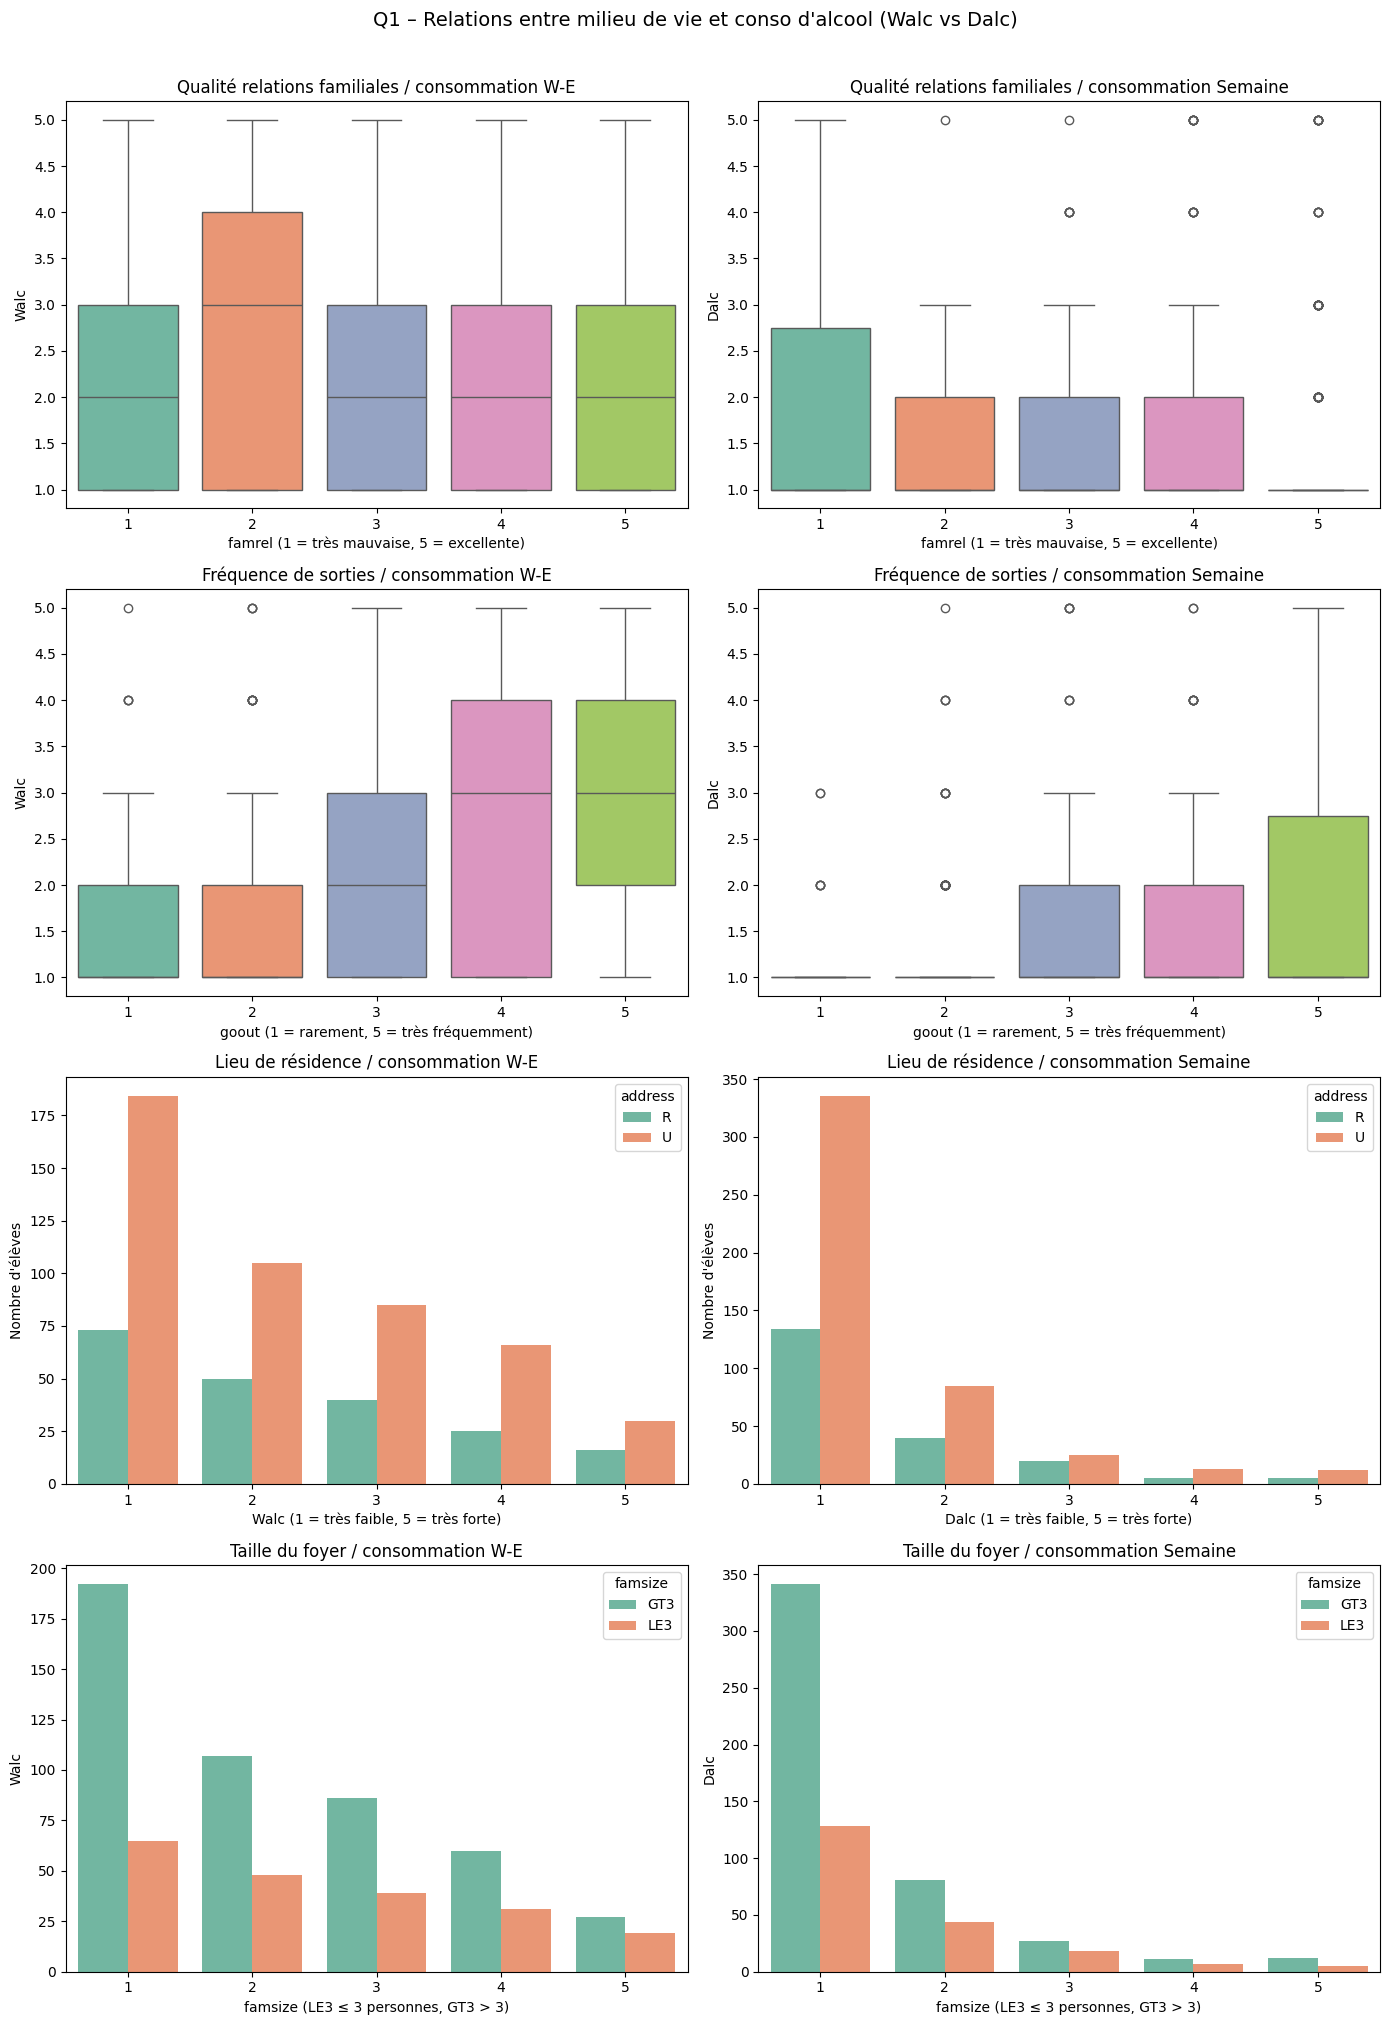

In [9]:
# Visualisations ciblées (Walc vs Dalc)
fig, axes = plt.subplots(4, 2, figsize=(14, 20))

# famrel
sns.boxplot(x="famrel", y="Walc", data=df, ax=axes[0, 0], palette="Set2", hue="famrel", legend=False)
axes[0, 0].set_title("Qualité relations familiales / consommation W-E")
axes[0, 0].set_xlabel("famrel (1 = très mauvaise, 5 = excellente)")
axes[0, 0].set_ylabel("Walc")
axes[0, 0].invert_yaxis() 

sns.boxplot(x="famrel", y="Dalc", data=df, ax=axes[0, 1], palette="Set2", hue="famrel", legend=False)
axes[0, 1].set_title("Qualité relations familiales / consommation Semaine")
axes[0, 1].set_xlabel("famrel (1 = très mauvaise, 5 = excellente)")
axes[0, 1].set_ylabel("Dalc")
axes[0, 1].invert_yaxis() 

# goout
sns.boxplot(x="goout", y="Walc", data=df, ax=axes[1, 0], palette="Set2", hue="goout", legend=False)
axes[1, 0].set_title("Fréquence de sorties / consommation W-E")
axes[1, 0].set_xlabel("goout (1 = rarement, 5 = très fréquemment)")
axes[1, 0].set_ylabel("Walc")
axes[1, 0].invert_yaxis() 

sns.boxplot(x="goout", y="Dalc", data=df, ax=axes[1, 1], palette="Set2", hue="goout", legend=False)
axes[1, 1].set_title("Fréquence de sorties / consommation Semaine")
axes[1, 1].set_xlabel("goout (1 = rarement, 5 = très fréquemment)")
axes[1, 1].set_ylabel("Dalc")
axes[1, 1].invert_yaxis() 

# address (Rural/Urbain)
sns.countplot(x="Walc", hue="address", data=df, ax=axes[2,0], palette="Set2")
axes[2, 0].set_title("Lieu de résidence / consommation W-E")
axes[2, 0].set_xlabel("Walc (1 = très faible, 5 = très forte)")
axes[2, 0].set_ylabel("Nombre d'élèves")

sns.countplot(x="Dalc", hue="address", data=df, ax=axes[2,1], palette="Set2")
axes[2, 1].set_title("Lieu de résidence / consommation Semaine")
axes[2, 1].set_xlabel("Dalc (1 = très faible, 5 = très forte)")
axes[2, 1].set_ylabel("Nombre d'élèves") 

# famsize
sns.countplot(x="Walc", hue="famsize", data=df, ax=axes[3,0], palette="Set2")
axes[3, 0].set_title("Taille du foyer / consommation W-E")
axes[3, 0].set_xlabel("famsize (LE3 ≤ 3 personnes, GT3 > 3)")
axes[3, 0].set_ylabel("Walc")

sns.countplot(x="Dalc", hue="famsize", data=df, ax=axes[3,1], palette="Set2")
axes[3, 1].set_title("Taille du foyer / consommation Semaine")
axes[3, 1].set_xlabel("famsize (LE3 ≤ 3 personnes, GT3 > 3)")
axes[3, 1].set_ylabel("Dalc")

plt.suptitle("Q1 – Relations entre milieu de vie et conso d'alcool (Walc vs Dalc)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


 ACP : var familiales/lifestyle+conso


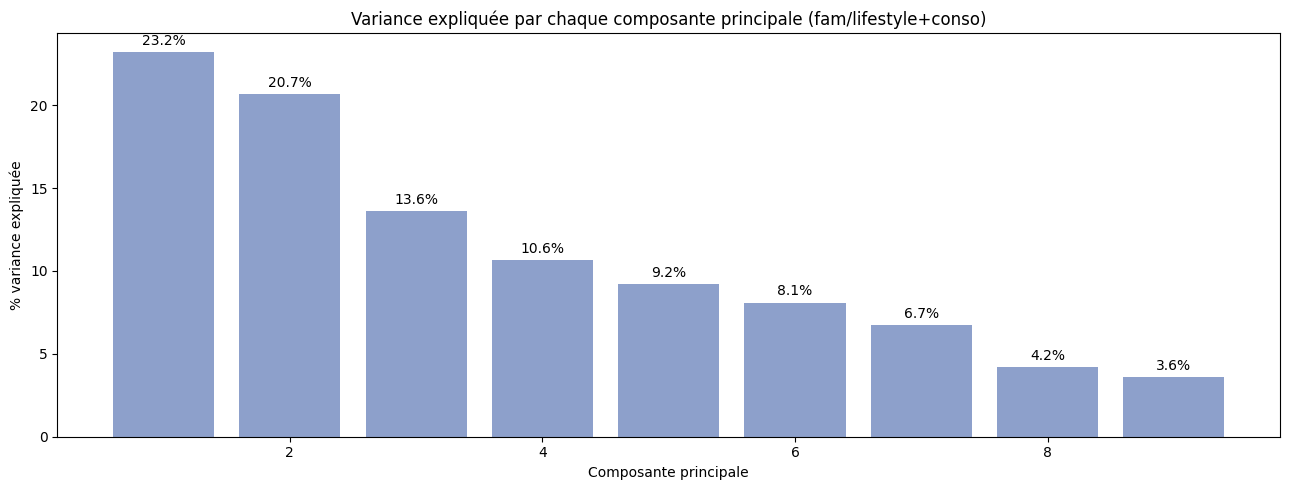

In [10]:
# ACP des var familiales/lifestyle+conso
print("\n ACP : var familiales/lifestyle+conso")
df_enc["failures"] = df_enc[["failures_mat", "failures_por"]].astype(float).mean(axis=1)
fam_lif_cons_cols = ["Medu", "Fedu", "famrel", "goout", "freetime",
               "Dalc", "Walc", "studytime", "failures"]

X_fam_lif_cons = df_enc[fam_lif_cons_cols]
Xsc = StandardScaler().fit_transform(X_fam_lif_cons)

pca = PCA(n_components=len(fam_lif_cons_cols))
pcs = pca.fit_transform(Xsc)

# Visualisation ACP
fig, axes = plt.subplots(1, 1, figsize=(13, 5))

bars = axes.bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_ * 100,
            color=sns.color_palette("Set2")[2])
axes.bar_label(bars, fmt='%.1f%%', padding=3)    
axes.set_xlabel("Composante principale")
axes.set_ylabel("% variance expliquée")
axes.set_title("Variance expliquée par chaque composante principale (fam/lifestyle+conso)")

plt.tight_layout()
plt.show()

In [11]:
# % inertie expliquée sur les 2 premières composantes principales de l'ACP fam/lif/conso
pca2 = PCA(n_components=2)
pcs2 = pca2.fit_transform(Xsc)
var_exp = pca2.explained_variance_ratio_ * 100
print(f"ACP à 2 composantes : {var_exp[0]:.1f}% + {var_exp[1]:.1f}% "
      f"= {sum(var_exp):.1f}% d'inertie expliquée")

ACP à 2 composantes : 23.2% + 20.7% = 43.9% d'inertie expliquée


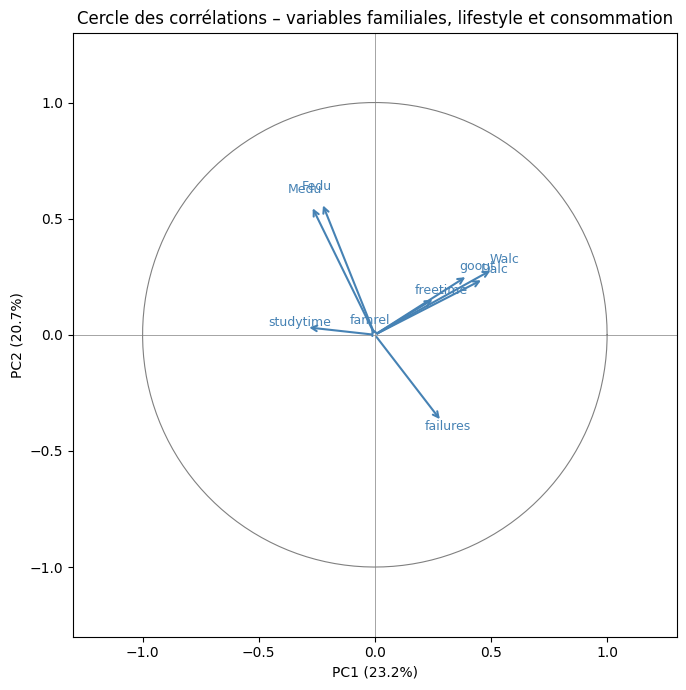

In [12]:
# Cercle des corrélations
fig, ax = plt.subplots(figsize=(7, 7))
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), color="grey", linewidth=0.8)
ax.axhline(0, color="grey", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)
for i, var in enumerate(fam_lif_cons_cols):
    ax.annotate("", xy=(pca2.components_[0, i], pca2.components_[1, i]),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="steelblue", lw=1.5))
    ax.text(pca2.components_[0, i] * 1.1,
            pca2.components_[1, i] * 1.1,
            var, fontsize=9, ha="center", color="steelblue")
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)")
ax.set_title("Cercle des corrélations – variables familiales, lifestyle et consommation")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

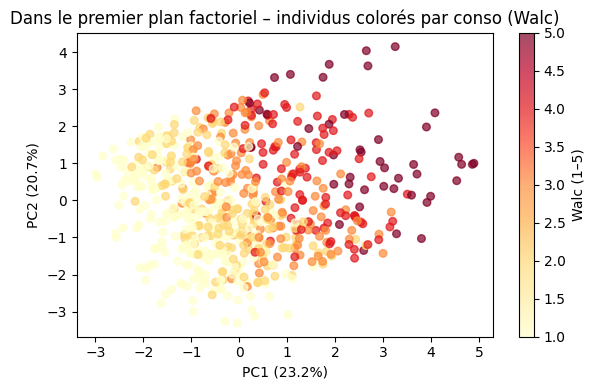

In [13]:
# Nuage des individus coloré par var
fig, ax = plt.subplots(figsize=(6, 4))
sc = ax.scatter(pcs2[:, 0], pcs2[:, 1],
                c=df["Walc"], cmap="YlOrRd", alpha=0.7, s=30)
plt.colorbar(sc, ax=ax, label="Walc (1–5)")
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)")
ax.set_title("Dans le premier plan factoriel – individus colorés par conso (Walc)")
plt.tight_layout()
plt.show()

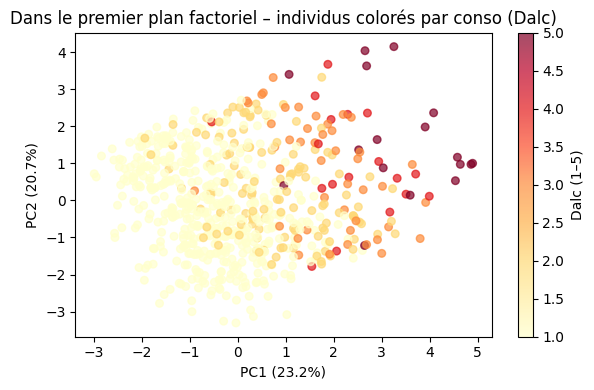

In [14]:
# Nuage des individus coloré par var
fig, ax = plt.subplots(figsize=(6, 4))
sc = ax.scatter(pcs2[:, 0], pcs2[:, 1],
                c=df["Dalc"], cmap="YlOrRd", alpha=0.7, s=30)
plt.colorbar(sc, ax=ax, label="Dalc (1–5)")
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)")
ax.set_title("Dans le premier plan factoriel – individus colorés par conso (Dalc)")
plt.tight_layout()
plt.show()

## Partie 3 – Q2 : Classification des profils

In [15]:
# Variables de comportement social retenues
behavior_cols = ["goout", "freetime", "Dalc", "Walc"]
X_beh = df_enc[behavior_cols]
Xsc_beh = StandardScaler().fit_transform(X_beh)

In [16]:
def kmeans_inertia(X, n_clusters_list, n_init=20):
    """Génère les inerties K-means pour une liste de K"""
    for k in n_clusters_list:
        cls = KMeans(n_clusters=k, init="k-means++", n_init=n_init,
                     random_state=42)
        cls.fit(X)
        yield k, cls.inertia_

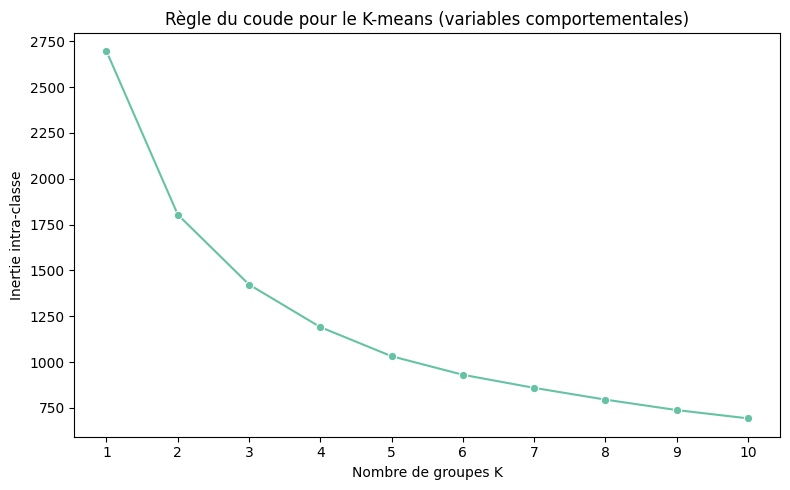

In [17]:
#Règle du coude pour determiner le K du K-means comportemental
k_range = range(1, 11)
inertia_records = list(kmeans_inertia(Xsc_beh, k_range))
df_inertia = pd.DataFrame(inertia_records, columns=["k", "inertie"])

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(x="k", y="inertie", data=df_inertia,
             marker="o", color=sns.color_palette("Set2")[0], ax=ax)
ax.set_xlabel("Nombre de groupes K")
ax.set_ylabel("Inertie intra-classe")
ax.set_title("Règle du coude pour le K-means (variables comportementales)")
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.tight_layout()
plt.show()


 K-means avec K = 2


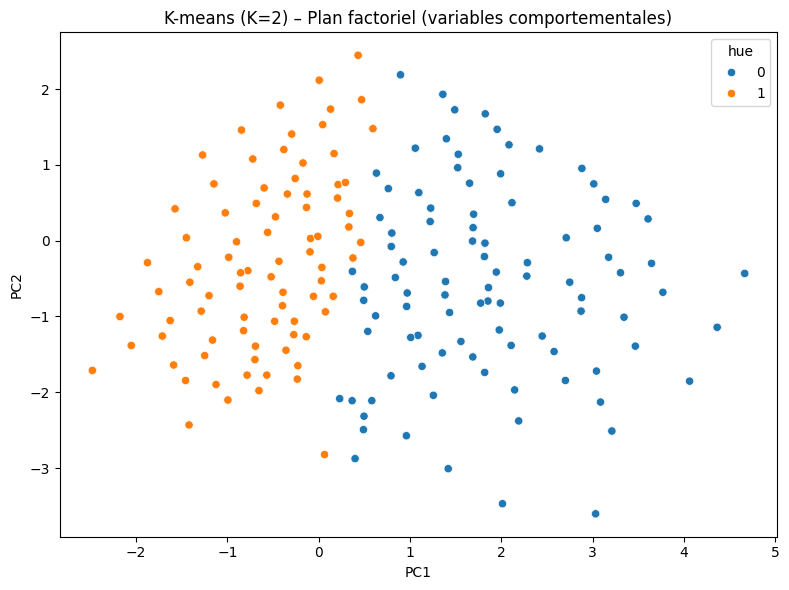


Profils moyens des clusters K-means :
            goout  freetime  Dalc  Walc     G3
cluster_km                                    
0             4.0      3.59  2.36  3.77  10.55
1             2.8      3.00  1.10  1.59  11.57


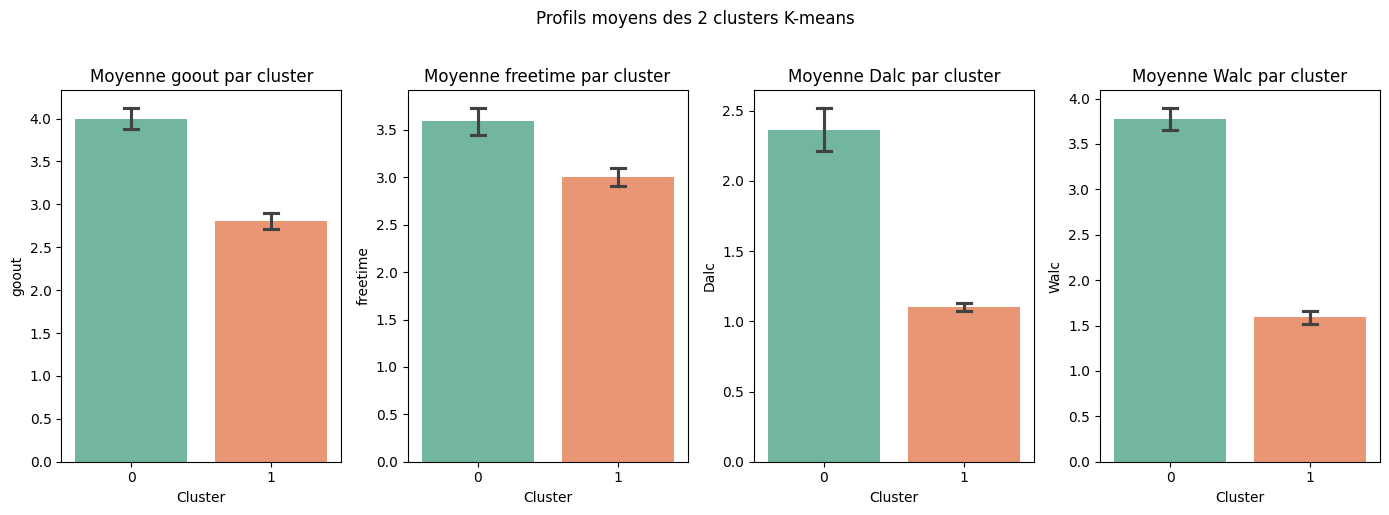

In [18]:
K_opt = 2  # val observée sur graphique précédent
print(f"\n K-means avec K = {K_opt}")

cls_km = KMeans(n_clusters=K_opt, init="k-means++", n_init=20, random_state=42)
cls_km.fit(Xsc_beh)
labels_km = cls_km.labels_

# Visualisation dans le plan ACP
fig, ax = plt.subplots(figsize=(8, 6))
scatterplot_pca(data=pd.DataFrame(Xsc_beh, columns=behavior_cols),
                hue=labels_km, ax=ax,
                title=f"K-means (K={K_opt}) – Plan factoriel (variables comportementales)")
plt.tight_layout()
plt.show()

# Profils moyens des clusters
df["cluster_km"] = labels_km
cols_to_agg = behavior_cols + ["G3"]
df_profils = df[cols_to_agg].copy()
for col in cols_to_agg:
    df_profils[col] = pd.to_numeric(df_profils[col], errors='coerce')

df_profils["cluster_km"] = df["cluster_km"]

print("\nProfils moyens des clusters K-means :")
print(df_profils.groupby("cluster_km")[cols_to_agg].mean().round(2).to_string())

# Barplot des profils
fig, axes = plt.subplots(1, len(behavior_cols), figsize=(14, 5))

for ax, col in zip(axes, behavior_cols):
    sns.barplot(x="cluster_km", y=col, data=df_profils, ax=ax, palette="Set2", hue="cluster_km", legend=False, capsize=0.1)
    ax.set_title(f"Moyenne {col} par cluster")
    ax.set_xlabel("Cluster")

plt.suptitle(f"Profils moyens des {K_opt} clusters K-means", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


 Classification Ascendante Hiérarchique (Ward)


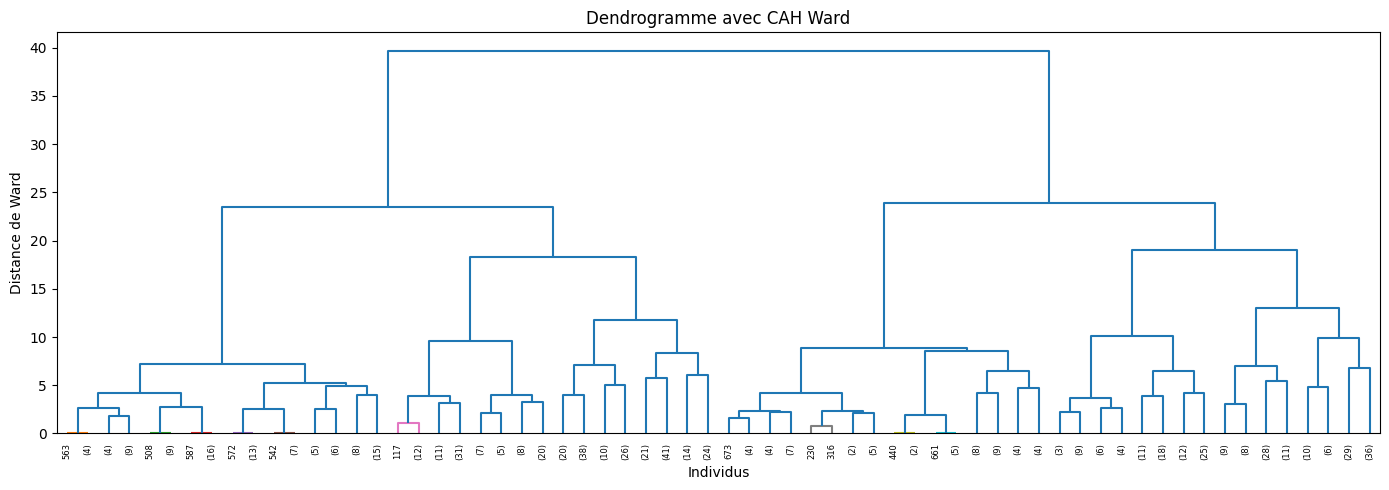

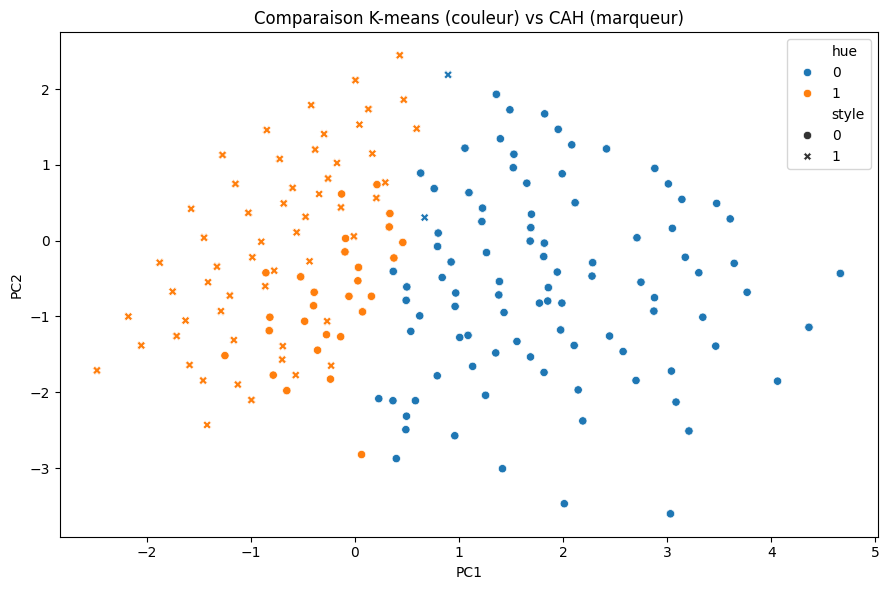

In [19]:
# Classification Ascendante Hiérarchique
print("\n Classification Ascendante Hiérarchique (Ward)")

cah = AgglomerativeClustering(
    metric="euclidean", linkage="ward",
    distance_threshold=0, n_clusters=None,
)
cah.fit(Xsc_beh)   

fig, ax = plt.subplots(figsize=(14, 5))
plot_dendrogram(cah, ax=ax,
                truncate_mode="level", p=5,
                color_threshold=1.5)
ax.set_title("Dendrogramme avec CAH Ward")
ax.set_xlabel("Individus")
ax.set_ylabel("Distance de Ward")
plt.tight_layout()
plt.show()

# Coupe du dendrogramme en K groupes
cah_k = AgglomerativeClustering(
    metric="euclidean", linkage="ward", n_clusters=K_opt
)
cah_k.fit(Xsc_beh)
labels_cah = cah_k.labels_

# Comparaison K-means vs CAH dans le plan ACP comportemental
fig, ax = plt.subplots(figsize=(9, 6))
scatterplot_pca(data=pd.DataFrame(Xsc_beh, columns=behavior_cols),
                hue=labels_km, style=labels_cah,
                ax=ax, title="Comparaison K-means (couleur) vs CAH (marqueur)")
plt.tight_layout()
plt.show()

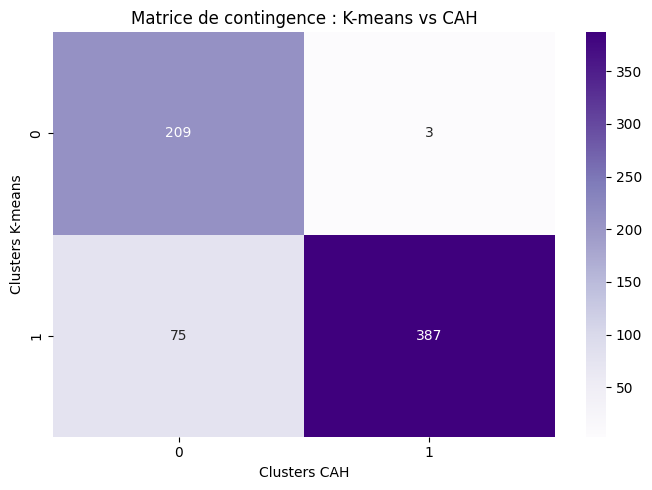

Indice de Rand (RI) : 0.7950
Indice de Rand Ajusté (ARI) : 0.5887


In [20]:
#Matrice de confusion croisée pour voir si K-Means a des résultats similaires à CAH
conf_matrix = pd.crosstab(labels_km, labels_cah, 
                          rownames=['Clusters K-means'], 
                          colnames=['Clusters CAH'])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples', ax=ax)
ax.set_title("Matrice de contingence : K-means vs CAH")
plt.tight_layout()
plt.show()

# Calcul des indices de Rand
ri = rand_score(labels_km, labels_cah)
ari = adjusted_rand_score(labels_km, labels_cah)

print(f"Indice de Rand (RI) : {ri:.4f}")
print(f"Indice de Rand Ajusté (ARI) : {ari:.4f}")

## Partie 4 – Q3 : Prédiction de la réussite scolaire

In [21]:
# Variables prédictives : comportement + assiduité + scolaire préalable
df_enc["G1"] = df[["G1_mat", "G1_por"]].mean(axis=1)
df_enc["G2"] = df[["G2_mat", "G2_por"]].mean(axis=1)
df_enc["absences"] = df[["absences_mat", "absences_por"]].mean(axis=1)

pred_cols = ["Dalc", "Walc", "studytime", "failures",
             "goout", "freetime", "G1", "G2", "absences"]
target_col = "reussite"   # G3 ≥ 10

X = df_enc[pred_cols]
y = df_enc[target_col]

Xsc_pred = StandardScaler().fit_transform(X)
X_df_sc = pd.DataFrame(Xsc_pred, columns=pred_cols)

print(f"\nDistribution de la variable cible :")
print(y.value_counts())
print(f"Proportion de réussite : {y.mean():.1%}")


Distribution de la variable cible :
reussite
1    500
0    174
Name: count, dtype: int64
Proportion de réussite : 74.2%


In [22]:
def validation_errors(X, y, models, cv=10):
    """Génère les accuracy de validation croisée"""
    for model, name in models:
        for acc in cross_val_score(model, X, y, cv=cv, scoring="accuracy"):
            yield name, acc


Validation croisée à 10 plis

Accuracy moyenne par modèle (validation croisée 10 plis) :
                         mean     std
Modèle                               
K-PPV (K=15)           0.8399  0.0298
LDA                    0.8977  0.0477
Naïf Bayésien          0.8413  0.0501
QDA                    0.8726  0.0523
Régression Logistique  0.9080  0.0539


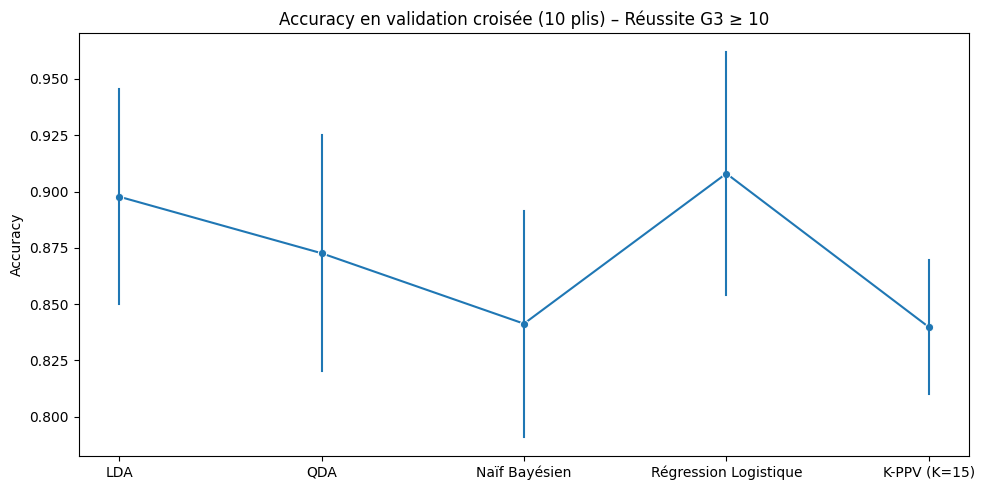

In [23]:
# Validation croisée à 10 plis (avec comparaison des modèles)
print("\nValidation croisée à 10 plis")

models = [
    (LinearDiscriminantAnalysis(),"LDA"),
    (QuadraticDiscriminantAnalysis(reg_param=0.1),"QDA"),
    (GaussianNB(),"Naïf Bayésien"),
    (LogisticRegression(max_iter=500),"Régression Logistique"),
    (KNeighborsClassifier(n_neighbors=15),"K-PPV (K=15)"),
]

gen = list(validation_errors(X_df_sc, y, models))
df_cv = pd.DataFrame(gen, columns=["Modèle", "Accuracy"])

print("\nAccuracy moyenne par modèle (validation croisée 10 plis) :")
print(df_cv.groupby("Modèle")["Accuracy"].agg(["mean", "std"]).round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x="Modèle", y="Accuracy", data=df_cv,
             err_style="bars", errorbar="sd",
             marker="o", ax=ax)
ax.set_title("Accuracy en validation croisée (10 plis) – Réussite G3 ≥ 10")
ax.set_ylabel("Accuracy")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [24]:
# Régression logistique linéaire

X_train, X_test, y_train, y_test = train_test_split(
    X_df_sc, y, test_size=0.25, random_state=42, stratify=y
)

lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul


Performance sur ensemble test : 0.9112


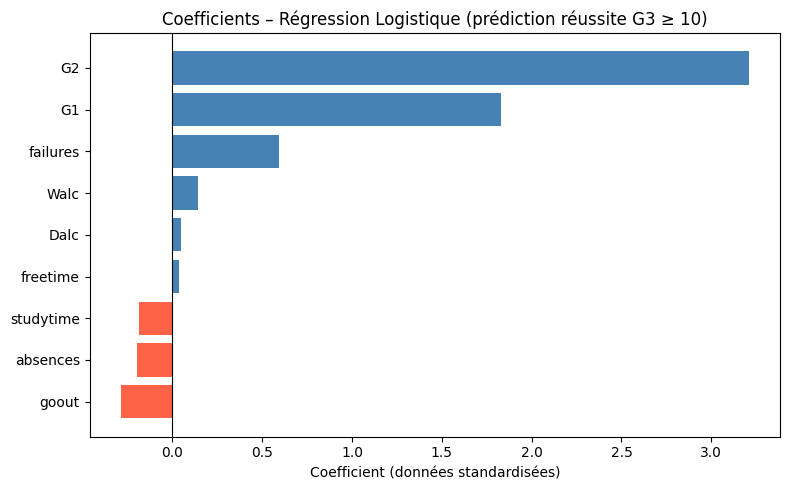

In [25]:
print(f"\nPerformance sur ensemble test : {lr.score(X_test, y_test):.4f}")

coef_df = pd.DataFrame({
    "Variable": pred_cols,
    "Coefficient": lr.coef_[0]
}).sort_values("Coefficient")

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["tomato" if c < 0 else "steelblue" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Variable"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Coefficients – Régression Logistique (prédiction réussite G3 ≥ 10)")
ax.set_xlabel("Coefficient (données standardisées)")
plt.tight_layout()
plt.show()

In [26]:
# Régression Logistique Quadratique
poly = PolynomialFeatures(degree=2)
X_train_quad = poly.fit_transform(X_train)

lr_quad = LogisticRegression(max_iter=500)
lr_quad.fit(X_train_quad, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul


Performance sur ensemble test : 0.8935


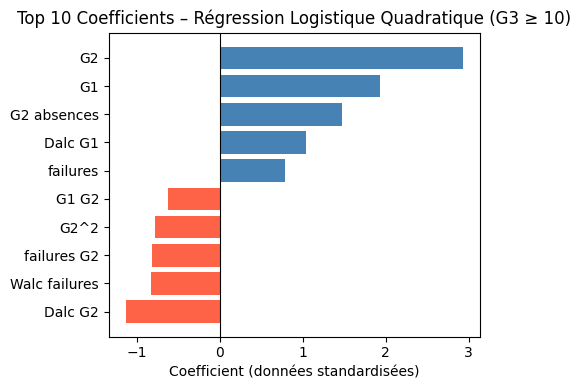

In [27]:
X_test_quad = poly.transform(X_test)
print(f"\nPerformance sur ensemble test : {lr_quad.score(X_test_quad, y_test):.4f}")

quad_cols = poly.get_feature_names_out(pred_cols)

coef_df = pd.DataFrame({
    "Variable": quad_cols,
    "Coefficient": lr_quad.coef_[0]
}).sort_values("Coefficient")

coef_df_top = pd.concat([coef_df.head(5), coef_df.tail(5)])

fig, ax = plt.subplots(figsize=(5, 4))
colors = ["tomato" if c < 0 else "steelblue" for c in coef_df_top["Coefficient"]]

ax.barh(coef_df_top["Variable"], coef_df_top["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)

ax.set_title("Top 10 Coefficients – Régression Logistique Quadratique (G3 ≥ 10)")
ax.set_xlabel("Coefficient (données standardisées)")

plt.tight_layout()
plt.show()

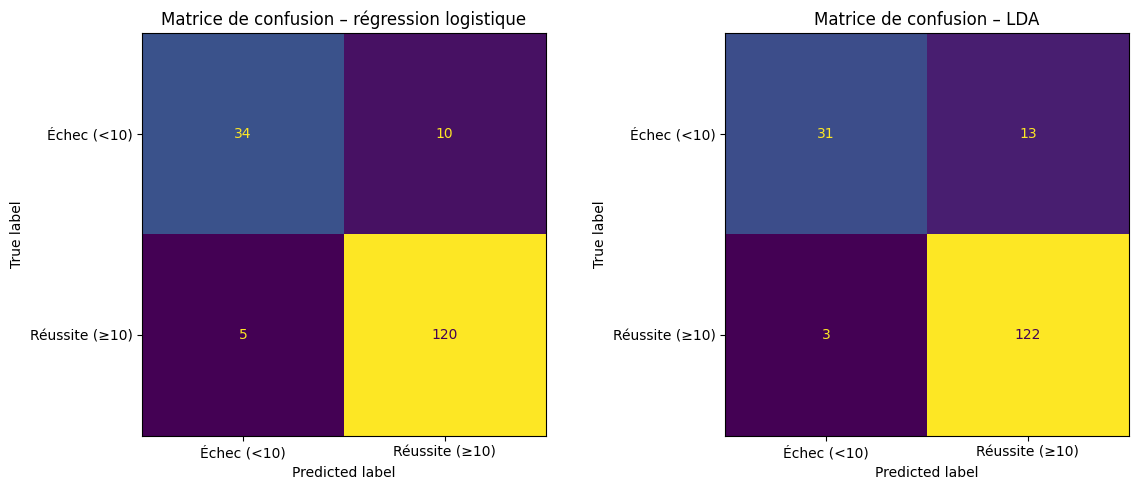

In [28]:
# Matrice de confusion Régrassion Logistique vs LDA (les deux modèles les plus accurates)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (model, name) in zip(axes, [
    (LogisticRegression(max_iter=500), "régression logistique"),
    (LinearDiscriminantAnalysis(), "LDA"),
]):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm,
                                   display_labels=["Échec (<10)", "Réussite (≥10)"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Matrice de confusion – {name}")

plt.tight_layout()
plt.show()

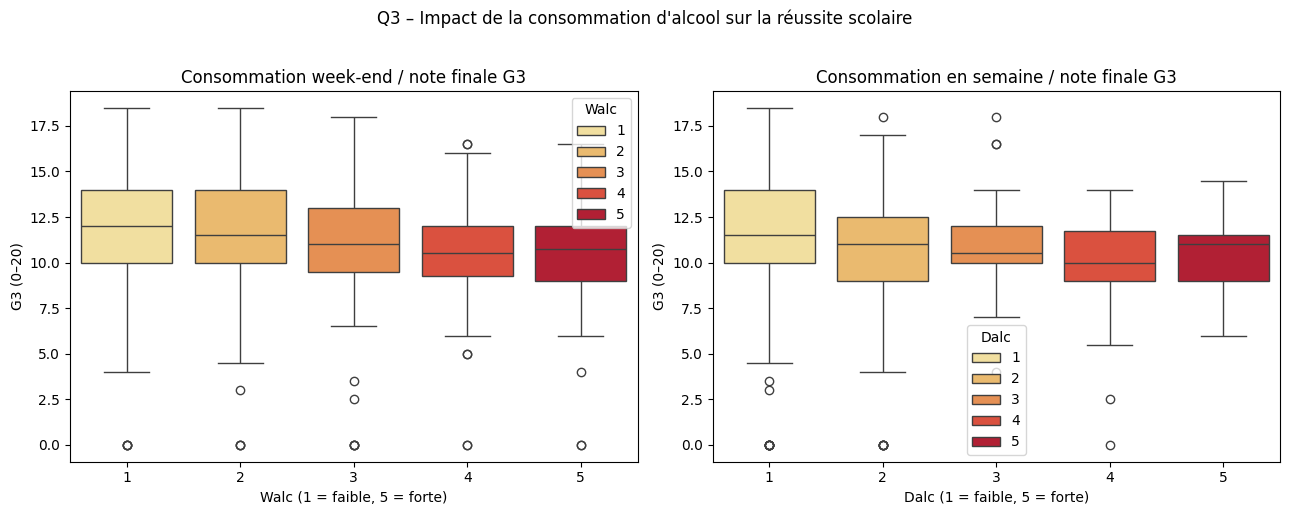

In [29]:
# Visualisation : conso vs notes"

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(x="Walc", hue="Walc", y="G3", data=df, ax=axes[0], palette="YlOrRd")
axes[0].set_title("Consommation week-end / note finale G3")
axes[0].set_xlabel("Walc (1 = faible, 5 = forte)")
axes[0].set_ylabel("G3 (0–20)")

sns.boxplot(x="Dalc", hue="Dalc", y="G3", data=df, ax=axes[1], palette="YlOrRd")
axes[1].set_title("Consommation en semaine / note finale G3")
axes[1].set_xlabel("Dalc (1 = faible, 5 = forte)")
axes[1].set_ylabel("G3 (0–20)")

plt.suptitle("Q3 – Impact de la consommation d'alcool sur la réussite scolaire",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

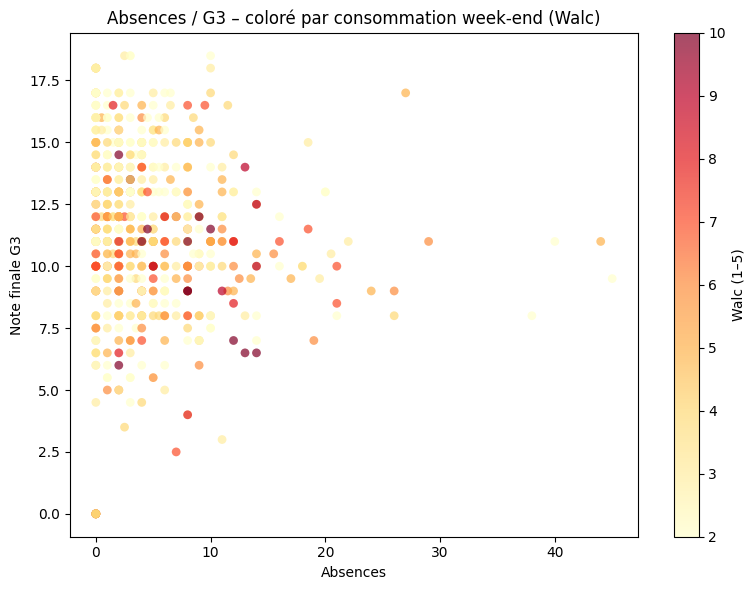

In [30]:
# absences + consommation
df["Walc"] = df["Walc"].astype(float)
df["Dalc"] = df["Dalc"].astype(float)
df["Totalc"] = df["Walc"] + df["Dalc"]
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(df["absences"], df["G3"],
                c=df["Totalc"], cmap="YlOrRd",
                alpha=0.7, s=40, edgecolors="none")
plt.colorbar(sc, ax=ax, label="Walc (1–5)")
ax.set_xlabel("Absences")
ax.set_ylabel("Note finale G3")
ax.set_title("Absences / G3 – coloré par consommation week-end (Walc)")
plt.tight_layout()
plt.show()

In [31]:
# Fonction qui calcule la vraisemblance d’un modèle de régression logistique (TD10)
def loglike_LR(model, X, y):
    targ = np.column_stack((1 - y, y))
    prob = model.predict_proba(X)
    return -log_loss(targ, prob, normalize=False)

# Fonction qui réalise le test de Wald sur les coefficients du modèle de régression appris (TD10)
def Waldtest_LR(model, X):
    prob = model.predict_proba(X)
    What = np.diag(np.prod(prob, axis=1))
    X_np = X.to_numpy()
    In_F = X_np.T @ What @ X_np
    shat = np.sqrt(np.diag(np.linalg.inv(In_F)))
    zscores = model.coef_ / shat
    nonsign = np.abs(zscores) <= spst.norm.ppf(1 - 0.05 / 2, loc=0, scale=1)
    return zscores, nonsign

In [32]:
X_ = cp.copy(X_train)
y_ = np.array(y_train)

cls = LogisticRegression(fit_intercept=False, penalty=None, solver="newton-cg")
cls.fit(X_, y_)
ll = loglike_LR(cls, X_, y_)

print(f"Départ : Modèle Complet ({X_.shape[1]} variables) | Log-Vraisemblance = {ll:.2f}\n")

cls_ = LogisticRegression(fit_intercept=False, penalty=None, solver="newton-cg")
cls_.fit(X_, y_)
ll_ = loglike_LR(cls_, X_, y_)

# Seuil du test du Chi-2
seuil_chi2 = spst.chi2.ppf(1 - 0.05, 1)

# Boucle d'élimination descendante
while 2 * (ll - ll_) <= seuil_chi2:
    Xopt = cp.copy(X_)
    clsopt = cp.copy(cls_)
    llopt = cp.copy(ll_)
    X_.drop(columns=X_.columns[np.abs(Waldtest_LR(cls_, X_)[0]).argmin()], inplace=True)
    cls_.fit(X_, y_)
    ll_ = loglike_LR(cls_, X_, y_)
print(Xopt.columns)
print(clsopt.coef_)

/home/thibault/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/thibault/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/thibault/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this w

Départ : Modèle Complet (9 variables) | Log-Vraisemblance = -237.04

Index(['Dalc', 'G2'], dtype='object')
[[0.11942626 2.07536267]]


/home/thibault/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/thibault/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/thibault/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this w

In [33]:
# tableau récapitulatif
df_interpretation = pd.DataFrame({
    "Variable conservée": Xopt.columns,
    "Coefficient (Beta)": clsopt.coef_[0],
    "Le Rapport de Cotes (Odds Ratio)": np.exp(clsopt.coef_[0])
}).sort_values(by="Coefficient (Beta)", ascending=False)

print(df_interpretation.to_string())

  Variable conservée  Coefficient (Beta)  Le Rapport de Cotes (Odds Ratio)
1                 G2            2.075363                          7.967436
0               Dalc            0.119426                          1.126850
